In [1]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report, recall_score, precision_score
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Conv3D, MaxPool2D, MaxPool3D, BatchNormalization, GlobalAveragePooling3D, GlobalAveragePooling2D, Dropout, Dense, Flatten

In [2]:
# Loading data

data = sio.loadmat("Indian_pines_corrected.mat")["indian_pines_corrected"]
labels = sio.loadmat("Indian_pines_gt.mat")["indian_pines_gt"]

height, width, bands = data.shape

print(data.shape)
print(labels.shape)

(145, 145, 200)
(145, 145)


In [3]:
# Preprocessing

# Flatter the pixels
X_flat = data.reshape(-1, bands)

#Scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

# Principal Component Analysis
n_components = 30
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Reshape to 3D
X_3D = X_pca.reshape(height, width, n_components)

#Padding
patch_size = 11
margin = patch_size // 2

X_pad = np.pad(X_3D, ((margin, margin), (margin, margin), (0, 0)), mode='constant')

In [4]:
X_pad.shape

(155, 155, 30)

In [5]:
# Selecting 5 samples per class

X_train, y_train = [], []
X_test, y_test = [], []


for class_id in range(1, 17):
    coords = np.argwhere(labels == class_id)
    
    np.random.seed(42)
    np.random.shuffle(coords)
    
    train_pts = coords[:5]
    test_pts = coords[5:]
    
    for r, c in train_pts:
        patch = X_pad[r : r + patch_size, c : c + patch_size, :]
        X_train.append(patch)
        y_train.append(class_id - 1)
        
    for r, c in test_pts:
        patch = X_pad[r : r + patch_size, c : c + patch_size, :]
        X_test.append(patch)
        y_test.append(class_id - 1)

# Tensor preparation
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

In [6]:
print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

Training Shape: (80, 11, 11, 30)
Testing Shape: (10169, 11, 11, 30)


In [7]:
# Data Augmentation
X_aug, y_aug = [], []

for i in range(len(X_train)):
    patch = X_train[i]
    label = y_train[i]
    
    X_aug.append(patch)
    X_aug.append(np.rot90(patch, k=1, axes=(0, 1)))
    X_aug.append(np.rot90(patch, k=1, axes=(0, 1)))
    X_aug.append(np.fliplr(patch))
    
    for _ in range(4): y_aug.append(label)

X_train_aug = np.array(X_aug)
y_train_aug = np.array(y_aug)

In [8]:
# Validation Split
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train_aug, y_train_aug, test_size=0.1,
                                                              stratify=y_train_aug, random_state=42)

In [9]:
X_train_final = np.expand_dims(X_train_final, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

In [10]:
X_train_final.shape

(288, 11, 11, 30, 1)

In [19]:
# Training

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)
es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

cnn_3D = Sequential([
    Conv3D(32, (3, 3, 3), activation='relu', input_shape=(11, 11, 30, 1), padding='same'),
    MaxPool3D((2, 2, 2)),
    BatchNormalization(),
    Conv3D(64, (3, 3, 3), activation='relu', padding='same'),
    MaxPool3D((2, 2, 2)),
    BatchNormalization(),
    Conv3D(128, (3, 3, 3), activation='relu', padding='same'),
    GlobalAveragePooling3D(),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(16, activation='softmax')
])

cnn_3D.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_3D = cnn_3D.fit(
    X_train_final, y_train_final,
    batch_size=32,
    epochs = 200,
    validation_data = (X_val, y_val),
    callbacks=[reduce_lr, es]
)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.1458 - loss: 2.6260 - val_accuracy: 0.0625 - val_loss: 2.8450 - learning_rate: 0.0010
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3160 - loss: 2.2147 - val_accuracy: 0.0625 - val_loss: 2.7905 - learning_rate: 0.0010
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4097 - loss: 1.8500 - val_accuracy: 0.0625 - val_loss: 2.6777 - learning_rate: 0.0010
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5000 - loss: 1.5949 - val_accuracy: 0.2812 - val_loss: 2.2351 - learning_rate: 0.0010
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6562 - loss: 1.2299 - val_accuracy: 0.4688 - val_loss: 1.9502 - learning_rate: 0.0010
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7465 - loss: 0.9183 - val_accuracy: 0.4375 - val_loss: 1.7315 - learning_rate: 0.0010
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7917 - loss: 0.8187 - val_accuracy: 

In [20]:
print("Train Acc: ", history_3D.history['accuracy'][-1])
print("Train Loss: ", history_3D.history['loss'][-1])
print("Val Acc: ", history_3D.history['val_accuracy'][-1])
print("Val Loss: ", history_3D.history['val_loss'][-1])

Train Acc:  0.9965277910232544
Train Loss:  0.015786416828632355
Val Acc:  1.0
Val Loss:  0.0017744157230481505


Text(0.5, 1.0, 'Training Curves')

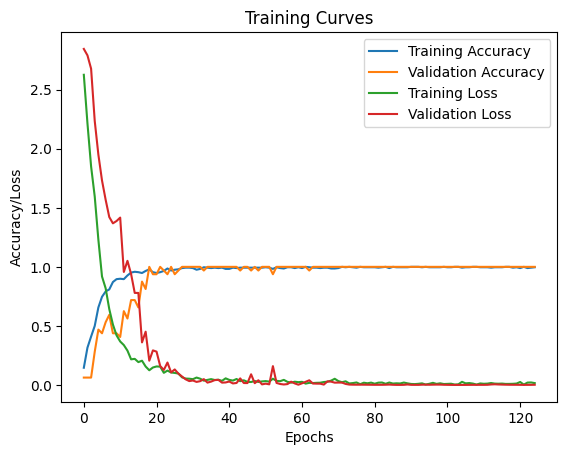

In [21]:
# Curve
plt.plot(history_3D.history['accuracy'], label='Training Accuracy')
plt.plot(history_3D.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history_3D.history['loss'], label='Training Loss')
plt.plot(history_3D.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy/Loss")
plt.title("Training Curves")




In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision: ", precision_score(y_test, y_pred, average='macro'))
print("Recall: ", recall_score(y_test, y_pred, average='macro'))
print("F1-Score: ", f1_score(y_test, y_pred, average='macro'))

In [24]:
# Testing
y_pred_probs = cnn_3D.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Precision: ", precision_score(y_test, y_pred, average="weighted"))
print("Recall: ", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score: ", f1_score(y_test, y_pred, average="weighted"))

318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Precision:  0.7241879907462225
Recall:  0.6790244861834989
F1 Score:  0.689236433248186
